# Superstore E-Commerce Sales Analysis
Final Data Analytics Project

## Task 1: Problem Definition
Analyze sales, profit, and trends in an E-commerce dataset using Python EDA.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [39]:
df = pd.read_csv('superstore_ecommerce_sample.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,ORD-10000,2022-04-13,2022-04-19,Same Day,CUST-1725,Customer_475,Corporate,India,Bangalore,...,626632,South,PROD-753,Technology,Machines,Scanner,964.66,6,0.02,125.41
1,2,ORD-10001,2023-03-12,2023-03-15,Same Day,CUST-6202,Customer_118,Consumer,India,Delhi,...,623864,North,PROD-152,Office Supplies,Paper,A4 Paper Pack,1655.02,4,0.08,115.85
2,3,ORD-10002,2022-09-28,2022-09-30,First Class,CUST-9082,Customer_136,Consumer,India,Bangalore,...,655779,North,PROD-302,Office Supplies,Paper,Notebook Pack,2028.37,2,0.10,101.42
3,4,ORD-10003,2022-04-17,2022-04-18,First Class,CUST-7893,Customer_316,Corporate,India,Kochi,...,604654,North,PROD-387,Technology,Accessories,Keyboard,2858.25,9,0.09,171.50
4,5,ORD-10004,2022-03-13,2022-03-19,Second Class,CUST-7188,Customer_331,Corporate,India,Hyderabad,...,673253,North,PROD-777,Furniture,Chairs,Executive Chair,1542.58,4,0.28,-200.54


In [40]:
df.shape

(1200, 21)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         1200 non-null   int64  
 1   Order ID       1200 non-null   object 
 2   Order Date     1200 non-null   object 
 3   Ship Date      1200 non-null   object 
 4   Ship Mode      1200 non-null   object 
 5   Customer ID    1200 non-null   object 
 6   Customer Name  1200 non-null   object 
 7   Segment        1200 non-null   object 
 8   Country        1200 non-null   object 
 9   City           1200 non-null   object 
 10  State          1200 non-null   object 
 11  Postal Code    1200 non-null   int64  
 12  Region         1200 non-null   object 
 13  Product ID     1200 non-null   object 
 14  Category       1200 non-null   object 
 15  Sub-Category   1200 non-null   object 
 16  Product Name   1200 non-null   object 
 17  Sales          1200 non-null   float64
 18  Quantity

In [42]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,650850.573333,2539.985742,4.996667,0.146183,10.561208
std,346.554469,29483.927437,1391.145402,2.590157,0.086213,247.303284
min,1.000000,600112.000000,201.600000,1.000000,0.000000,-670.740000
25%,300.750000,625061.500000,1314.432500,3.000000,0.070000,-130.170000
50%,600.500000,651720.500000,2487.865000,5.000000,0.150000,0.000000
75%,900.250000,677059.000000,3733.265000,7.000000,0.220000,144.930000
max,1200.000000,699946.000000,4989.540000,9.000000,0.300000,739.780000


## Task 2: Data Preprocessing

In [43]:
df.ffill(inplace=True)

In [44]:
df.drop_duplicates(inplace=True)

In [45]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])
print(df.head())

   Row ID   Order ID Order Date  Ship Date     Ship Mode Customer ID  \
0       1  ORD-10000 2022-04-13 2022-04-19      Same Day   CUST-1725   
1       2  ORD-10001 2023-03-12 2023-03-15      Same Day   CUST-6202   
2       3  ORD-10002 2022-09-28 2022-09-30   First Class   CUST-9082   
3       4  ORD-10003 2022-04-17 2022-04-18   First Class   CUST-7893   
4       5  ORD-10004 2022-03-13 2022-03-19  Second Class   CUST-7188   

  Customer Name    Segment Country       City  ... Postal Code  Region  \
0  Customer_475  Corporate   India  Bangalore  ...      626632   South   
1  Customer_118   Consumer   India      Delhi  ...      623864   North   
2  Customer_136   Consumer   India  Bangalore  ...      655779   North   
3  Customer_316  Corporate   India      Kochi  ...      604654   North   
4  Customer_331  Corporate   India  Hyderabad  ...      673253   North   

  Product ID         Category Sub-Category     Product Name    Sales  \
0   PROD-753       Technology     Machines        

In [46]:
df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month
print(df.head())

   Row ID   Order ID Order Date  Ship Date     Ship Mode Customer ID  \
0       1  ORD-10000 2022-04-13 2022-04-19      Same Day   CUST-1725   
1       2  ORD-10001 2023-03-12 2023-03-15      Same Day   CUST-6202   
2       3  ORD-10002 2022-09-28 2022-09-30   First Class   CUST-9082   
3       4  ORD-10003 2022-04-17 2022-04-18   First Class   CUST-7893   
4       5  ORD-10004 2022-03-13 2022-03-19  Second Class   CUST-7188   

  Customer Name    Segment Country       City  ... Product ID  \
0  Customer_475  Corporate   India  Bangalore  ...   PROD-753   
1  Customer_118   Consumer   India      Delhi  ...   PROD-152   
2  Customer_136   Consumer   India  Bangalore  ...   PROD-302   
3  Customer_316  Corporate   India      Kochi  ...   PROD-387   
4  Customer_331  Corporate   India  Hyderabad  ...   PROD-777   

          Category Sub-Category     Product Name    Sales Quantity Discount  \
0       Technology     Machines          Scanner   964.66        6     0.02   
1  Office Supplies

## Task 3: EDA

In [47]:
df.groupby('Category')['Sales'].sum()

Category
Furniture           963869.48
Office Supplies    1018727.78
Technology         1065385.63
Name: Sales, dtype: float64

In [48]:
df.groupby('Region')['Profit'].sum()

Region
North     1473.37
South    -2198.09
West     13398.17
Name: Profit, dtype: float64

## Visualizations

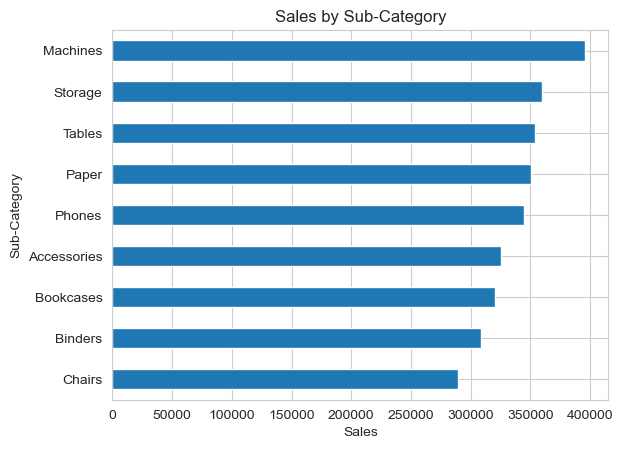

In [49]:
plt.figure()
df.groupby('Sub-Category')['Sales'].sum().sort_values().plot(kind='barh')
plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")
plt.show()

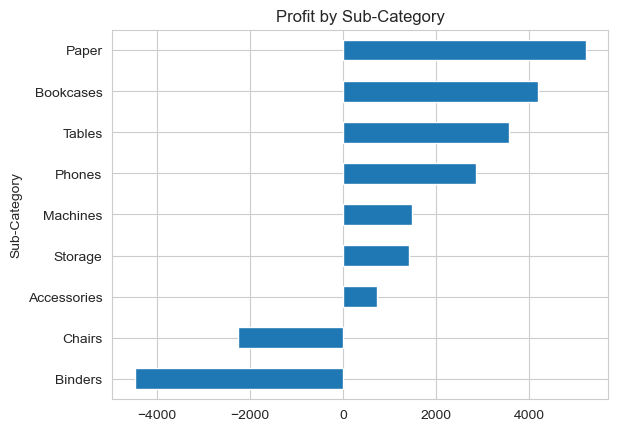

In [50]:
plt.figure()
df.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='barh')
plt.title("Profit by Sub-Category")
plt.show()

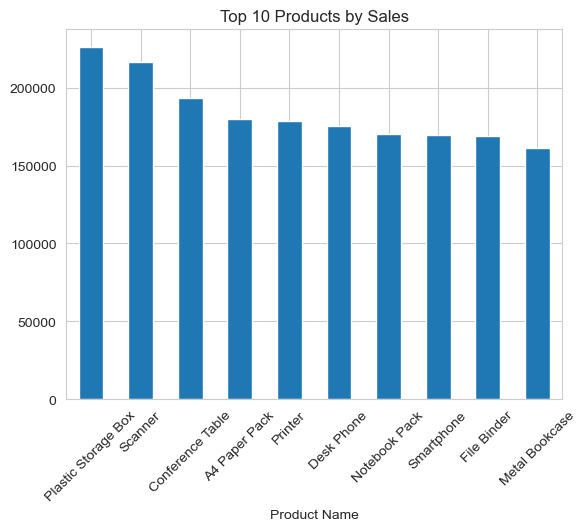

In [51]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xticks(rotation=45)
plt.show()

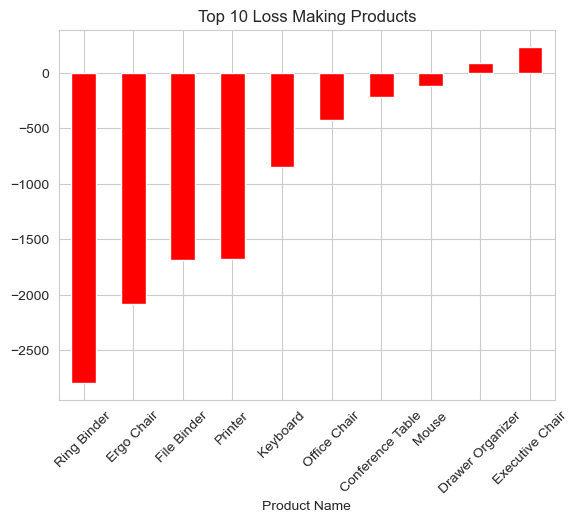

In [52]:
loss_products = df.groupby('Product Name')['Profit'].sum().nsmallest(10)

loss_products.plot(kind='bar', color='red')
plt.title("Top 10 Loss Making Products")
plt.xticks(rotation=45)
plt.show()

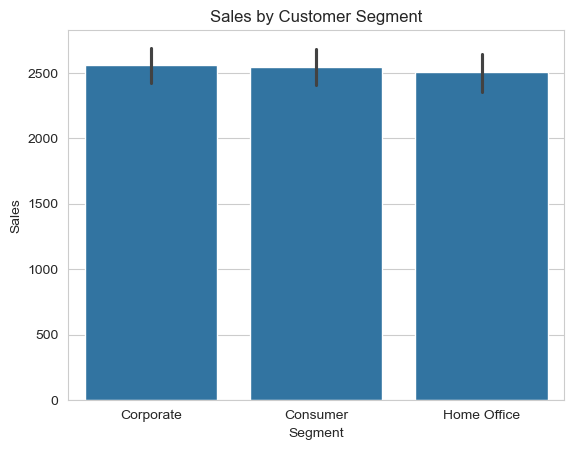

In [53]:
sns.barplot(x='Segment', y='Sales', data=df)
plt.title("Sales by Customer Segment")
plt.show()

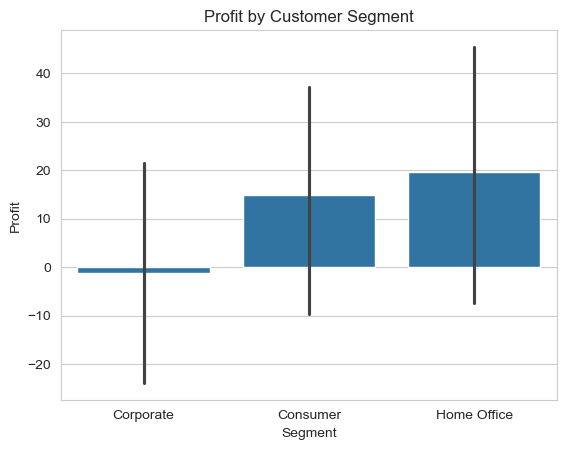

In [54]:
sns.barplot(x='Segment', y='Profit', data=df)
plt.title("Profit by Customer Segment")
plt.show()

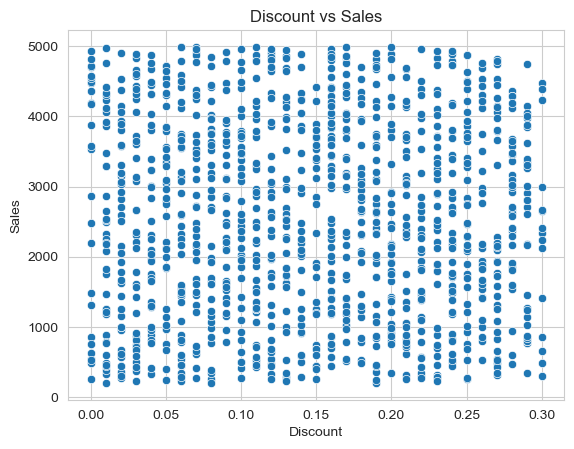

In [55]:
sns.scatterplot(x='Discount', y='Sales', data=df)
plt.title("Discount vs Sales")
plt.show()

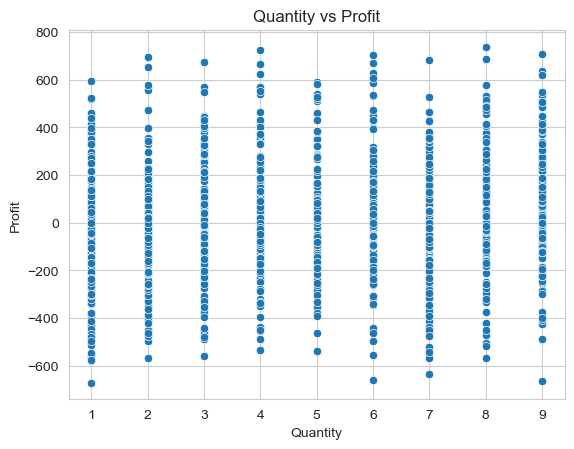

In [56]:
sns.scatterplot(x='Quantity', y='Profit', data=df)
plt.title("Quantity vs Profit")
plt.show()

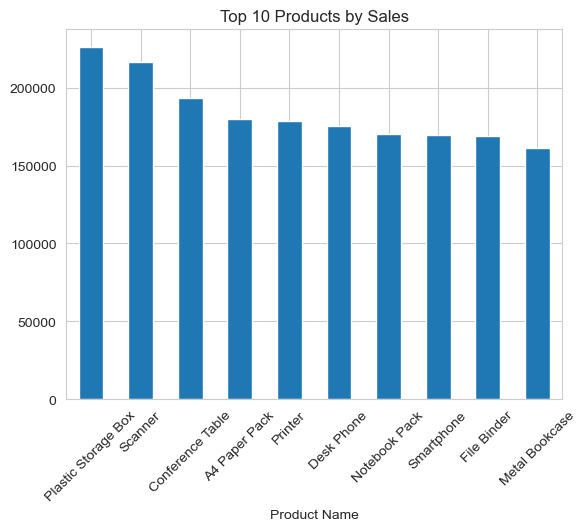

In [57]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xticks(rotation=45)
plt.show()

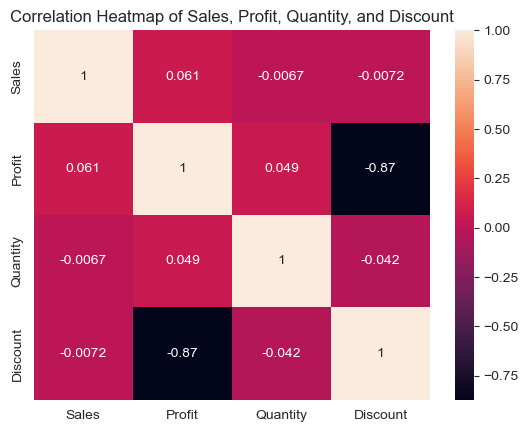

In [58]:
    sns.heatmap(df[['Sales','Profit','Quantity','Discount']].corr(), annot=True)
    plt.title("Correlation Heatmap of Sales, Profit, Quantity, and Discount")
    plt.show()

## Task 4: Insights
1. Technology leads sales
    The analysis shows that the Technology category generates the highest sales revenue compared to Furniture and Office Supplies.
This indicates that products such as phones, accessories, and machines are in high demand among customers.

         Interpretation:

Technology products have higher prices and frequent demand
Customers are willing to spend more on tech-related items

        Business Recommendation:

Increase stock and variety in Technology category
Focus marketing campaigns on high-performing tech products
2.  Discounts reduce profit

The analysis shows that the Technology category generates the highest sales revenue compared to Furniture and Office Supplies.
This indicates that products such as phones, accessories, and machines are in high demand among customers.

        Interpretation:

Technology products have higher prices and frequent demand
Customers are willing to spend more on tech-related items

         Business Recommendation:

Increase stock and variety in Technology category
Focus marketing campaigns on high-performing tech products


3. Regional variation exists
    Sales and profit vary significantly across different regions such as South, West, and North.
Some regions generate higher revenue, while others may have lower sales or profitability.

         Interpretation:

Customer preferences differ by region
Market demand is not uniform across locations

        Business Recommendation:

Focus on high-performing regions for expansion
Improve marketing and logistics in low-performing regions

4. Seasonal trends observed
    Sales and profit vary significantly across different regions such as South, West, and North.
Some regions generate higher revenue, while others may have lower sales or profitability.

        Interpretation:

Customer preferences differ by region
Market demand is not uniform across locations

        Business Recommendation:

Focus on high-performing regions for expansion
Improve marketing and logistics in low-performing regions

5. Few products dominate
   A small number of products contribute to a large portion of total sales revenue.

         Interpretation:

High-performing products are key revenue drivers
Some products have very low contribution

         Business Recommendation:

Focus on top-selling products
Improve or remove low-performing products
     

## Conclusion
EDA completed successfully with insights.